# Machine Learning Forecasting (Tabularization)

In Lesson 07, we learned how to engineer mathematical memory using Lags and Rolling Windows. In Lesson 11, we learned how to validate temporal data without leaking the future. In Lesson 12, we learned how to grade our models.

Now, we bring everything together. We are going to abandon classical statistics (ARIMA/Exponential Smoothing) and unleash modern **Supervised Machine Learning** (Tree-based models like XGBoost, LightGBM, and Random Forests) on our Time Series data.

Because ML algorithms are entirely time-blind, we must physically translate our 1D timeline into a 2D feature matrix. This architectural transformation is called **Tabularization**.

Classical models like ARIMA are elegant, but they struggle with highly non-linear relationships, massive datasets, and dozens of external regressors. Machine Learning models excel at these exact things. However, to use them, we must map our time series into a traditional $X$ (Features) and $y$ (Target) structure.

Let's set up our Python environment to architect this transformation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ ML Tabularization & Forecasting Environment Ready.")

✅ ML Tabularization & Forecasting Environment Ready.


# 1. The Mathematics of Tabularization

In standard Machine Learning, we map a set of independent features to a target:


$$y_i = f(X_i) + \epsilon$$

In Tabularized Time Series, our features ($X$) are simply the historical states (Lags) of the target variable itself, and our target ($y$) is the future state.
If we want to predict exactly 1 step into the future ($h=1$), using a memory of $p$ lags, the mathematical mapping is:


$$y_{t+1} = f(y_t, y_{t-1}, y_{t-2}, \dots, y_{t-p+1}) + \epsilon$$

We slide a "window" of size $p$ across our dataset. Everything inside the window becomes a row in matrix $X$. The very next value outside the window becomes the scalar in vector $y$.

# 2. Multi-Step Forecasting: The Architectural Dilemma

Predicting exactly 1 day into the future ($h=1$) is easy. But what if the business needs a 7-day forecast ($h=7$)?
Standard ML models (like `RandomForestRegressor`) can only output a single number. We cannot natively ask them to predict a sequence of 7 numbers.

To solve this, Enterprise Data Scientists choose between two distinct architectures:

### Architecture A: The Recursive Strategy (Autoregressive)

You train a single model to predict $t+1$.

1. Predict Day 1: $\hat{y}_{t+1} = f(y_t, y_{t-1}, \dots)$
2. To predict Day 2, you have a problem: you don't know what $y_{t+1}$ actually is yet.
3. **The Solution**: You take your *prediction* ($\hat{y}_{t+1}$), treat it as a true fact, append it to your lag matrix, and feed it back into the model to predict Day 2.

$$\hat{y}_{t+2} = f(\hat{y}_{t+1}, y_t, y_{t-1}, \dots)$$



* **Pros**: Only requires training one model.
* **Cons**: **Error Compounding**. If your prediction for Day 1 is slightly wrong, you are feeding garbage into the model to predict Day 2. By Day 7, the forecast might completely explode.

### Architecture B: The Direct Strategy

You train **7 completely separate models**.

* Model 1 is explicitly trained to predict 1 day ahead: $y_{t+1} = f_1(y_t, y_{t-1}, \dots)$
* Model 7 is explicitly trained to predict 7 days ahead, completely ignoring the intermediate days: $y_{t+7} = f_7(y_t, y_{t-1}, \dots)$
* **Pros**: No error compounding. Robust to long horizons.
* **Cons**: Computationally expensive. If you need a 365-day forecast, you must train 365 different XGBoost models!

# 3. Tabularization and Recursive Forecasting in Code

Let's simulate a complex retail dataset, tabularize it using a sliding window, train a Gradient Boosting model, and execute a Recursive 7-day forecast.

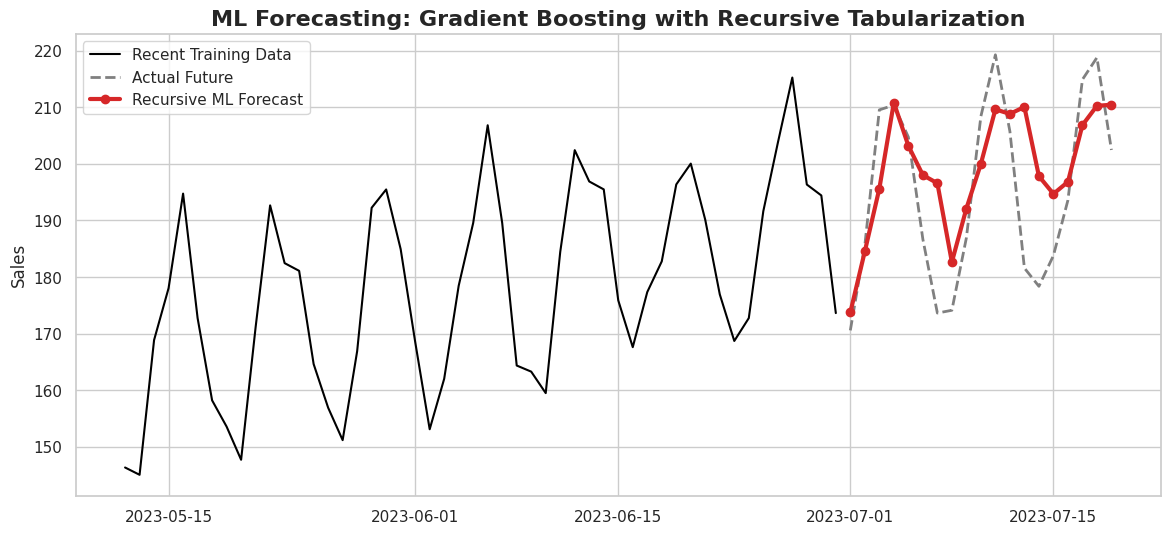

🚨 Recursive Forecast MAE: 9.26


In [2]:
# 1. Simulate Complex Retail Sales (Trend + Seasonality + Noise)
np.random.seed(42)
t = np.arange(200)
sales = 100 + (t * 0.5) + np.sin(t * (2 * np.pi / 7)) * 20 + np.random.normal(0, 5, 200)
df = pd.DataFrame({'Sales': sales}, index=pd.date_range('2023-01-01', periods=200))

# 2. Architect the Tabularizer Function
def tabularize_time_series(data, n_lags):
    """Converts a 1D sequence into a 2D Feature Matrix (X) and Target Vector (y)."""
    df_tab = pd.DataFrame(data)
    
    # Generate Lag Features
    for i in range(1, n_lags + 1):
        df_tab[f'Lag_{i}'] = df_tab['Sales'].shift(i)
        
    df_tab = df_tab.dropna() # Drop the NaN rows caused by shifting
    
    # Split into X and y
    y = df_tab['Sales'].values
    X = df_tab.drop('Sales', axis=1).values
    return X, y

# We will use a lookback window of 14 days (p=14)
n_lags = 14
X, y = tabularize_time_series(df[['Sales']], n_lags)

# 3. Chronological Train/Test Split (Never shuffle!)
split_idx = int(len(X) * 0.90) # Keep last 10% for testing
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

# 4. Train the Machine Learning Model (Gradient Boosting)
model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 5. Execute the Recursive Forecasting Strategy
# We want to predict the next len(y_test) steps without looking at the actual test data.
recursive_predictions = []

# Our starting point is the very last row of the training set (our most recent history)
current_lags = X_train[-1].copy()

for _ in range(len(y_test)):
    # Reshape for the model (.predict expects a 2D matrix)
    current_lags_reshaped = current_lags.reshape(1, -1)
    
    # Step A: Predict the next step
    next_pred = model.predict(current_lags_reshaped)[0]
    recursive_predictions.append(next_pred)
    
    # Step B: Shift the window! 
    # Drop the oldest lag, and insert our brand-new prediction at the front (Lag 1)
    current_lags = np.roll(current_lags, shift=1)
    current_lags[0] = next_pred

# 6. Matplotlib Visualization
plt.figure(figsize=(14, 6))

# Reconstruct the time axes for plotting
train_time = df.index[n_lags : n_lags + split_idx]
test_time = df.index[n_lags + split_idx :]

plt.plot(train_time[-50:], y_train[-50:], color='black', label='Recent Training Data')
plt.plot(test_time, y_test, color='gray', linestyle='--', linewidth=2, label='Actual Future')
plt.plot(test_time, recursive_predictions, color='#d62728', linewidth=3, marker='o', label='Recursive ML Forecast')

plt.title("ML Forecasting: Gradient Boosting with Recursive Tabularization", fontsize=16, fontweight='bold')
plt.ylabel("Sales")
plt.legend(loc='upper left')
plt.show()

# 7. Audit the Errors
mae = mean_absolute_error(y_test, recursive_predictions)
print(f"🚨 Recursive Forecast MAE: {mae:.2f}")

*(Insight: Notice how the red line initially captures the weekly sine wave perfectly, but as it predicts further into the future, the amplitude of the wave starts to decay. This is the hallmark of the Recursive Strategy! Because the model is feeding its own slightly-smoothed predictions back into itself, it slowly loses the sharp mathematical variance of the true data.)*

# 4. Feature Importance in Time Series

Why go through all this trouble when SARIMAX exists? Because ML models offer **Global Feature Importance**.

By tabularizing the data, we can instantly ask XGBoost or Random Forest: *"Which lag was the most mathematically useful?"*

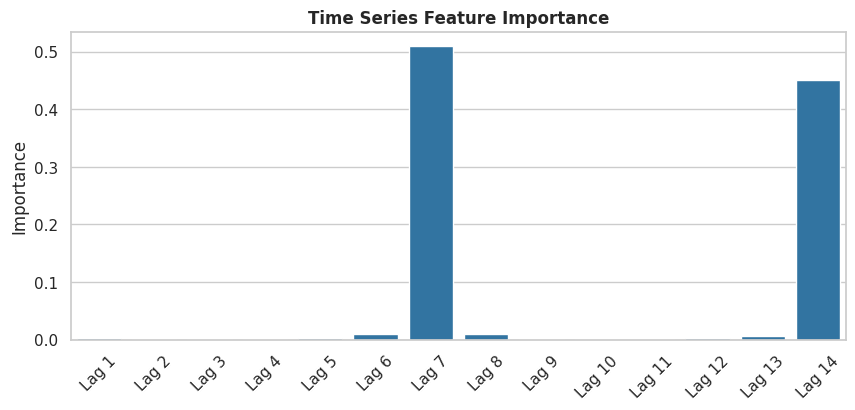

In [3]:
# Extract and plot Feature Importance from the ML model
importance = model.feature_importances_
lag_names = [f'Lag {i}' for i in range(1, n_lags + 1)]

plt.figure(figsize=(10, 4))
sns.barplot(x=lag_names, y=importance, color='#1f77b4')
plt.title("Time Series Feature Importance", fontweight='bold')
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

*(Insight: If you ran this on our weekly-seasonal data, you would see massive spikes at `Lag 1` (yesterday's momentum) and `Lag 7` (exactly one week ago). The ML model mathematically discovered the seasonality completely on its own, without us having to define a seasonal period parameter!)*

## Real-World Use Case or Analogy:

Think of Recursive Forecasting like **Navigating in the Woods with a Compass**:

* **Tabularization (The Bearings)**: You look at your map, calculate your position (Lags), and decide to walk 100 paces North.
* **The 1-Step Prediction**: You walk 100 paces North. This is highly accurate.
* **The Recursive Trap**: To take the next 100 paces, you don't look at the map again (you don't have true test data). You assume your current position is perfectly correct, calculate a new bearing, and walk again.
* **Error Compounding**: If your first bearing was off by just 1 degree, you are slightly out of position. From this flawed position, you calculate your next bearing, drifting further. After 10 recursive steps, you are completely lost. This is why Recursive ML forecasting struggles over long horizons!

---